# Boundary effect simulation
This simulation examines the boundary effect of shrub vegetation at the vegetation-desert interface. This effect is manifested as an increase in patch size and a sudden collapse of coverage under a disturbance gradient.

Environmental disturbance was incorporated into the simulation. It is assumed that under conditions of shifting sand disturbance, plants exhibit stronger facilitative strength and a larger negative radius to resist disturbance. The simulation starts from a pattern of enlarged shrub spots, and the system's response is observed under different disturbance intensities.

The results reveal that accompanying the disappearance of the Turing pattern, the system's stable density undergoes a nonlinear, rapid collapse.

In [4]:
import numpy as np
import pandas as pd
from scipy.signal import convolve2d, fftconvolve
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import cv2

# kernel generation tool
def create_circle_matrix(R, kernel_size):
    """
    创建圆形矩阵核 | Create a circular matrix kernel
    
    Parameters:
    -----------
    R : float
        圆的半径 | Radius of the circle
    kernel_size : int
        核的大小（必须是奇数）| Kernel size (must be odd)
    
    Returns:
    --------
    matrix : numpy.ndarray
        二值圆形矩阵 | Binary circular matrix
    """
    if kernel_size % 2 == 0:
        raise ValueError("kernel_size must be an odd number")
    
    matrix = np.zeros((kernel_size, kernel_size), dtype=int)
    center_x, center_y = kernel_size // 2, kernel_size // 2
    
    for i in range(kernel_size):
        for j in range(kernel_size):
            distance = np.sqrt((i - center_x) ** 2 + (j - center_y) ** 2)
            if distance <= R:
                matrix[i, j] = 1
    
    return matrix

## Define the kernels

In [5]:
# 网格大小 | Grid size
n = 200

# 资源供给水平 | Resource supply level
s = 0.7

# 定义物种1核（灌木）| Define Species 1 Kernel (Shrub)
rn1 = 40   # 负效应半径 | Negative effect radius
rp1 = 4    # 正效应半径 | Positive effect radius
c1 = 5     # 资源消耗率 | Resource consumption rate
# 创建负效应核 | Create negative effect kernel
kn1 = create_circle_matrix(rn1, 81)
nn1 = np.count_nonzero(kn1)
# 创建正效应核 | Create positive effect kernel
kp1 = create_circle_matrix(rp1, 81)
np1 = np.count_nonzero(kp1)
# 计算物种1的综合核 | Calculate combined kernel for Shrub
kn1 = kn1 * (c1/s) / nn1 - kp1 * 0.05



# 定义物种2核（草地）| Define Species 2 Kernel (Grass)
rn2 = 3    # 负效应半径 | Negative effect radius
rp2 = 1    # 正效应半径 | Positive effect radius
c2 = 3     # 资源消耗率 | Resource consumption rate
# 创建负效应核 | Create negative effect kernel
kn2 = create_circle_matrix(rn2, 7)
nn2 = np.count_nonzero(kn2)
# 创建正效应核 | Create positive effect kernel
kp2 = create_circle_matrix(rp2, 7)
np2 = np.count_nonzero(kp2)
# 计算物种2的综合核 | Calculate combined kernel for grass
kn2 = kn2 * (c2/s) / nn2 - kp2 * 0.01

## Creat inital spots pattern

迭代步数 | Step: 0
迭代步数 | Step: 200
迭代步数 | Step: 400
迭代步数 | Step: 600
迭代步数 | Step: 800
迭代步数 | Step: 1000
迭代步数 | Step: 1200
迭代步数 | Step: 1400
迭代步数 | Step: 1600
迭代步数 | Step: 1800


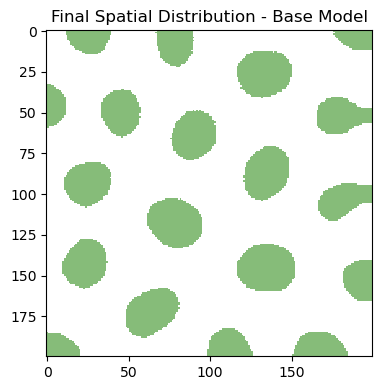

In [8]:
# 初始密度 | Initial densities
p1 = 0.001  # 物种1初始密度 | Initial species 1 density
p2 = 0.0    # 物种2初始密度 | Initial species 2 density

# 创建初始分布矩阵 | Create initial distribution matrix
# 0: 空地 | Empty, 1: 物种1 | Species 1, 2: 物种2 | Species 2
matrix = np.random.choice([0, 1, 2], size=(n, n), p=[1-p1-p2, p1, p2])
matrix1 = matrix == 1  # 物种1分布 | Species 1 distribution
matrix2 = matrix == 2  # 物种2分布 | Species 2 distribution

# 记录密度变化 | Record density changes
density1 = []  # 物种1密度 | Species 1 density
density2 = []  # 物种2密度 | Species 2 density

# 保存初始状态 | Save initial state
matback1 = matrix1.copy()
matback2 = matrix2.copy()



steps = 2000  # 迭代步数 | Number of steps

for i in range(steps):
    # 扩散过程 | Dispersal process
    p1 = 0.5 * np.count_nonzero(matrix1) / n / n
    p2 = 0.5 * np.count_nonzero(matrix2) / n / n
    
    # 生成扩散矩阵（只在空地上）| Generate dispersal matrix (only on empty cells)
    matrix_dispersal = np.random.choice([0, 1, 2], size=(n, n), 
                                        p=[(1-p1-p2), p1, p2]) * (1-np.logical_or(matrix1, matrix2))
    matrix_dispersal1 = matrix_dispersal == 1
    matrix_dispersal2 = matrix_dispersal == 2
    
    # 合并现有植被和新扩散的植被 | Combine existing and newly dispersed vegetation
    matrix_arena1 = np.logical_or(matrix_dispersal1, matrix1)
    matrix_arena2 = np.logical_or(matrix_dispersal2, matrix2)
    
    # 扩展矩阵以进行卷积 | Pad matrices for convolution
    pad_width1 = ((kn1.shape[0] - 1) // 2, (kn1.shape[1] - 1) // 2)
    matrix_ext1 = np.pad(matrix_arena1, pad_width=pad_width1, mode='symmetric')
    netEffect1 = fftconvolve(matrix_ext1, kn1, mode='valid')
    
    pad_width2 = ((kn2.shape[0] - 1) // 2, (kn2.shape[1] - 1) // 2)
    matrix_ext2 = np.pad(matrix_arena2, pad_width=pad_width2, mode='symmetric')
    netEffect2 = fftconvolve(matrix_ext2, kn2, mode='valid')
    
    # 总影响场 | Total influence field
    netEffect = netEffect1 + netEffect2
    
    # 植被动态（基于影响场）| Vegetation dynamics (based on influence field)
    H1 = 1.0   # 物种1阈值 | Species 1 threshold
    H2 = 1.1   # 物种2阈值 | Species 2 threshold
    
    prob1 = matrix1 - (netEffect - H1) * 0.5
    prob2 = matrix2 - (netEffect - H2) * 0.5
    
    # 更新植被分布 | Update vegetation distribution
    matrix1 = (np.random.rand(n, n) < prob1) * matrix_arena1
    matrix2 = (np.random.rand(n, n) < prob2) * matrix_arena2
    
    # 记录密度 | Record densities
    density1.append(np.count_nonzero(matrix1) / n / n)
    density2.append(np.count_nonzero(matrix2) / n / n)
    
    #if i % 200 == 0:
    #    print(f"迭代步数 | Step: {i}")

plt.figure(figsize=(5, 4))
cmap = mcolors.LinearSegmentedColormap.from_list('custom_cmap', ['white', '#86BC79'])
plt.imshow(matrix1 + 2*matrix2, cmap=cmap, interpolation='nearest')
plt.title('Final Spatial Distribution - Base Model')
plt.tight_layout()
plt.savefig("Sanddune.pdf", dpi=600, bbox_inches='tight')
plt.show()

## Disturbance Intensity Sensitivity Analysis

In [9]:
# 干扰强度敏感性分析 | Disturbance Intensity Sensitivity Analysis

# 恢复初始状态 | Restore initial state
matrix1 = matback1.copy()
matrix2 = matback2.copy()

print(f"初始物种1数量 | Initial species 1 count: {np.sum(matrix1)}")

# 初始化结果列表 | Initialize result lists
final1 = []  # 最终物种1密度 | Final species 1 density
final2 = []  # 最终物种2密度 | Final species 2 density
sequence = np.arange(0.6, 1, 0.005)  # 干扰强度序列（存活概率）| Disturbance intensity sequence (survival probability)

# 对不同干扰强度进行模拟 | Simulate for different disturbance intensities

for pd1 in sequence:
    #print(f"处理干扰强度 | Processing disturbance intensity: {pd1:.3f}")
    
    # 重置初始状态 | Reset to initial state
    matrix1 = matback1.copy()
    matrix2 = matback2.copy()
    
    density1 = []
    density2 = []
    steps = 500
    
    for i in range(steps):
        # 干扰过程 | Disturbance process
        disturbance = np.random.choice([True, False], size=(n, n), p=[1-pd1, pd1])
        matrix1 = np.logical_and(disturbance, matrix1)
        
        # 局部扩散过程（物种1的克隆繁殖）| Local dispersal process (clonal reproduction of species 1)
        kp1_local = create_circle_matrix(4, 9).astype(np.uint8)
        propzone = (cv2.dilate(matrix1.astype(np.uint8), kp1_local, iterations=1) - matrix1).astype(bool)
        pp1 = 0.2  # 局部扩散概率 | Local dispersal probability
        prop = np.random.choice([True, False], size=(n, n), p=[pp1, 1-pp1])
        propzone = np.logical_and(propzone, prop)
        
        # 长距离扩散过程 | Long-distance dispersal process
        p1 = 1.0 * np.count_nonzero(matrix1) / n / n
        p2 = 1.0 * np.count_nonzero(matrix2) / n / n
        
        matrix_dispersal = np.random.choice([0, 1, 2], size=(n, n), 
                                           p=[(1-p1-p2), p1, p2]) * (1-np.logical_or(matrix1, matrix2))
        matrix_dispersal1 = matrix_dispersal == 1
        matrix_dispersal2 = matrix_dispersal == 2
        
        # 合并局部扩散和长距离扩散 | Combine local and long-distance dispersal
        matrix_dispersal1 = np.logical_or(matrix_dispersal1, propzone)
        
        # 合并现有植被和新扩散的植被 | Combine existing and newly dispersed vegetation
        matrix_arena1 = np.logical_or(matrix_dispersal1, matrix1)
        matrix_arena2 = np.logical_or(matrix_dispersal2, matrix2)
        
        # 扩展矩阵以进行卷积 | Pad matrices for convolution
        pad_width1 = ((kn1.shape[0] - 1) // 2, (kn1.shape[1] - 1) // 2)
        matrix_ext1 = np.pad(matrix_arena1, pad_width=pad_width1, mode='symmetric')
        netEffect1 = fftconvolve(matrix_ext1, kn1, mode='valid')
        
        pad_width2 = ((kn2.shape[0] - 1) // 2, (kn2.shape[1] - 1) // 2)
        matrix_ext2 = np.pad(matrix_arena2, pad_width=pad_width2, mode='symmetric')
        netEffect2 = fftconvolve(matrix_ext2, kn2, mode='valid')
        
        # 总影响场 | Total influence field
        netEffect = netEffect1 + netEffect2
        
        # 植被动态（基于影响场）| Vegetation dynamics (based on influence field)
        prob1 = matrix1 - (netEffect - 1.0) * 1.0
        prob2 = matrix2 - (netEffect - 1.1) * 0.5
        
        # 更新植被分布 | Update vegetation distribution
        matrix1 = (np.random.rand(n, n) < prob1) * matrix_arena1
        matrix2 = (np.random.rand(n, n) < prob2) * matrix_arena2
        
        matrix1b = matrix1.copy()
        density1.append(np.count_nonzero(matrix1) / n / n)
        density2.append(np.count_nonzero(matrix2) / n / n)
    
    # 记录最终结果 | Record final results
    final1.append(np.sum(matrix1) / n / n)
    final2.append(np.sum(matrix2) / n / n)


初始物种1数量 | Initial species 1 count: 38
处理干扰强度 | Processing disturbance intensity: 0.600
处理干扰强度 | Processing disturbance intensity: 0.605
处理干扰强度 | Processing disturbance intensity: 0.610
处理干扰强度 | Processing disturbance intensity: 0.615
处理干扰强度 | Processing disturbance intensity: 0.620
处理干扰强度 | Processing disturbance intensity: 0.625
处理干扰强度 | Processing disturbance intensity: 0.630
处理干扰强度 | Processing disturbance intensity: 0.635
处理干扰强度 | Processing disturbance intensity: 0.640
处理干扰强度 | Processing disturbance intensity: 0.645
处理干扰强度 | Processing disturbance intensity: 0.650
处理干扰强度 | Processing disturbance intensity: 0.655
处理干扰强度 | Processing disturbance intensity: 0.660
处理干扰强度 | Processing disturbance intensity: 0.665
处理干扰强度 | Processing disturbance intensity: 0.670
处理干扰强度 | Processing disturbance intensity: 0.675
处理干扰强度 | Processing disturbance intensity: 0.680
处理干扰强度 | Processing disturbance intensity: 0.685
处理干扰强度 | Processing disturbance intensity: 0.690
处理干扰强度 | Processing disturbance

## Display of sudden vegetation collapse

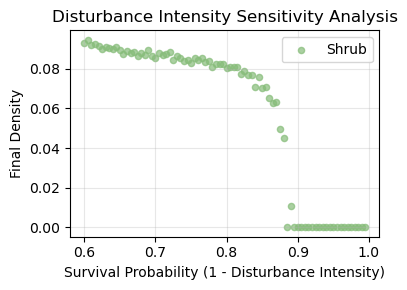

In [10]:
# 敏感性分析结果可视化 | Visualization of Sensitivity Analysis Results
plt.figure(figsize=(4, 3))
plt.scatter(sequence, final1, c="#86BC79", label='Shrub', s=20, alpha=0.7)
plt.xlabel('Disturbance Intensity')
plt.ylabel('Final Density')
plt.title('Disturbance Intensity Sensitivity Analysis')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
#plt.savefig("disturbance.pdf", dpi=600, bbox_inches='tight')
plt.show()

## Visualization of spatial pattern at different disturbance level

模拟干扰强度 | Simulating disturbance intensity: 0.65
迭代步数 | Step: 0
迭代步数 | Step: 100
迭代步数 | Step: 200
迭代步数 | Step: 300
迭代步数 | Step: 400


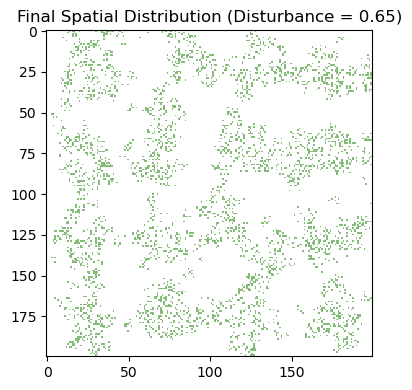

In [11]:
# 特定干扰强度下的格局模拟 | Pattern Simulation at Specific Disturbance Intensity
pd1 = 0.65  # 特定干扰强度 | Specific disturbance intensity 

# 恢复初始状态 | Restore initial state
matrix1 = matback1.copy()
matrix2 = matback2.copy()

density1 = []
density2 = []
steps = 500


print(f"模拟干扰强度 | Simulating disturbance intensity: {pd1}")
for i in range(steps):
    # 干扰过程 | Disturbance process
    disturbance = np.random.choice([True, False], size=(n, n), p=[1-pd1, pd1])
    matrix1 = np.logical_and(disturbance, matrix1)
    
    # 局部扩散过程 | Local dispersal process
    kp1_local = create_circle_matrix(4, 9).astype(np.uint8)
    propzone = (cv2.dilate(matrix1.astype(np.uint8), kp1_local, iterations=1) - matrix1).astype(bool)
    pp1 = 0.2
    prop = np.random.choice([True, False], size=(n, n), p=[pp1, 1-pp1])
    propzone = np.logical_and(propzone, prop)
    
    # 长距离扩散过程 | Long-distance dispersal process
    p1 = 1.0 * np.count_nonzero(matrix1) / n / n
    p2 = 1.0 * np.count_nonzero(matrix2) / n / n
    
    matrix_dispersal = np.random.choice([0, 1, 2], size=(n, n), 
                                       p=[(1-p1-p2), p1, p2]) * (1-np.logical_or(matrix1, matrix2))
    matrix_dispersal1 = matrix_dispersal == 1
    matrix_dispersal2 = matrix_dispersal == 2
    
    # 合并扩散 | Combine dispersal
    matrix_dispersal1 = np.logical_or(matrix_dispersal1, propzone)
    
    # 合并现有植被和新扩散的植被 | Combine existing and newly dispersed vegetation
    matrix_arena1 = np.logical_or(matrix_dispersal1, matrix1)
    matrix_arena2 = np.logical_or(matrix_dispersal2, matrix2)
    
    # 扩展矩阵以进行卷积 | Pad matrices for convolution
    pad_width1 = ((kn1.shape[0] - 1) // 2, (kn1.shape[1] - 1) // 2)
    matrix_ext1 = np.pad(matrix_arena1, pad_width=pad_width1, mode='symmetric')
    occupation1 = fftconvolve(matrix_ext1, kn1, mode='valid')
    
    pad_width2 = ((kn2.shape[0] - 1) // 2, (kn2.shape[1] - 1) // 2)
    matrix_ext2 = np.pad(matrix_arena2, pad_width=pad_width2, mode='symmetric')
    occupation2 = fftconvolve(matrix_ext2, kn2, mode='valid')
    
    # 总影响场 | Total influence field
    occupation = occupation1 + occupation2
    
    # 植被动态 | Vegetation dynamics
    prob1 = matrix1 - (occupation - 1.0) * 1.0
    prob2 = matrix2 - (occupation - 1.1) * 0.5
    
    # 更新植被分布 | Update vegetation distribution
    matrix1 = (np.random.rand(n, n) < prob1) * matrix_arena1
    matrix2 = (np.random.rand(n, n) < prob2) * matrix_arena2
    
    matrix1b = matrix1.copy()
    density1.append(np.count_nonzero(matrix1) / n / n)
    density2.append(np.count_nonzero(matrix2) / n / n)
    
    if i % 100 == 0:
        print(f"迭代步数 | Step: {i}")


plt.figure(figsize=(4, 4))
cmap = mcolors.LinearSegmentedColormap.from_list('custom_cmap', ['white', '#86BC79'])
plt.imshow(matrix1 + 2*matrix2, cmap=cmap, interpolation='nearest')
plt.title(f'Final Spatial Distribution (Disturbance intensity = {pd1})')
plt.tight_layout()
plt.show()